# SpaPath OSCC workflow

This notebook follows one linear workflow: load two single-cell references and the GSM6339632_s2 disease data, attach image embeddings when needed, preprocess and build graphs, learn initial embeddings, cluster, integrate, detect pathological regions, construct the all-gene disease dataset, and evaluate TC-to-LE enrichment against ground-truth tissue labels.

## 0. Setup

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import scanpy as sc
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

import spapath_model
import spapath_utils

warnings.filterwarnings("ignore")

In [2]:
DATASET_ID = "OSCC"
REFERENCE_SECTIONS = ["GM241", "BM169"]
DISEASE_SECTION = "GSM6339632_s2"
DEVICE = "cuda"
SEED = 123

DATA_ROOT = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_ROOT / DATASET_ID
OUTPUT_DIR = PROJECT_ROOT / "outputs" / DATASET_ID
FIGURE_DIR = OUTPUT_DIR / "fig"
TC_LE_GENE_FILE = PROJECT_ROOT / "notebook" / "TC_LE_genes.csv"
HE_IMAGE_PATH = (
    PROJECT_ROOT
    / "data"
    / DATASET_ID
    / "GSM6339632_s2_tissue_hires_image.png"
)

for output_path in (OUTPUT_DIR, FIGURE_DIR):
    spapath_utils.create_dir(output_path)

adata_type_map = {
    REFERENCE_SECTIONS[0]: "sc",
    REFERENCE_SECTIONS[1]: "sc",
    DISEASE_SECTION: "ST_with_HE",
}
sections = list(adata_type_map)

CELLTYPE_PALETTE = {
    "core": "#E09F3E",
    "transitory": "#C8553D",
    "edge": "#8E3B46",
    "normal": "#5C7A72",
    "nc": "#5C7A72",
}

REGION_PALETTE = {
    "Pathological regions": "#B6473F",
    "Healthy-like regions": "#6DBBD1",
}

/home/wuyd/SpaPath/outputs/OSCC has been created or already exists.
/home/wuyd/SpaPath/outputs/OSCC/fig has been created or already exists.


## 1. Read reference and disease data

In [3]:
reference_adatas = [
    sc.read_h5ad(PROCESSED_DIR / f"{section}.h5ad")
    for section in REFERENCE_SECTIONS
]
disease_adata = sc.read_h5ad(PROCESSED_DIR / f"{DISEASE_SECTION}.h5ad")

## 2. Attach image embeddings when needed

In [4]:
if "image_embedding" not in disease_adata.obsm:
    embedding_path = (
        PROCESSED_DIR
        / "spatial"
        / f"{DISEASE_SECTION}_image_embeddings.csv"
    )
    spapath_utils.attach_image_embedding(disease_adata, embedding_path)

image_embedding_dim = disease_adata.obsm["image_embedding"].shape[1]
for reference_adata in reference_adatas:
    reference_adata.obsm["image_embedding"] = np.zeros(
        (reference_adata.n_obs, image_embedding_dim),
        dtype=np.float32,
    )

## 3. Preprocess data and build graphs

In [5]:
batch_list = [*reference_adatas, disease_adata]
adata_full, disease_adata_all_genes = spapath_utils.preprocess(
    adata_list=batch_list,
    adata_type_map=adata_type_map,
    full_num_hvgs=3000,
    min_genes_qc=10,
    min_cells_qc=10,
)

adata_full = spapath_utils.build_graph_GAT_plus(
    adata_full=adata_full,
    adata_type_map=adata_type_map,
    K=8,
    img_threshold=0.0,
)

shape of adata 0 before quality control: (3781, 33681)
shape of adata 0 after quality control: (3781, 13542)
shape of adata 1 before quality control: (3637, 33681)
shape of adata 1 after quality control: (3637, 15726)
shape of adata 2 before quality control: (1749, 36588)
shape of adata 2 after quality control: (1749, 15031)
Find 11771 shared genes among datasets.
Normalize data...
Find 3000 shared highly variable genes among datasets.
Start building graphs...
Skipping spatial graph for batch GM241 (sc)
Skipping spatial graph for batch BM169 (sc)
Building sparse graph for batch GSM6339632_s2 (ST_with_HE) using NearestNeighbors...
  Image similarity quantiles (neighbors only): [-0.61168084  0.03298008  0.19500548  0.36825496  1.        ]
  Average neighbors for Slice GSM6339632_s2: 6.08


## 4. Learn initial embeddings

In [6]:
model = spapath_model.Model(
    adata_full=adata_full,
    adata_type_map=adata_type_map,
    lr_pre=1e-4,
    lr=1e-4,
    n_pre_training_steps=500,
    n_training_steps=300,
    device=DEVICE,
    seed=SEED,
)

adata_full = model.initial_embedding()

Pretrain slice 2: 100%|██████████| 500/500 [00:01<00:00, 345.85it/s]


## 5. Cluster observations

In [7]:
adata_full = model.clustering(
    init_res=1.5,
    intopk=40,
)

There are 16 initial clusters for Slice - 0
There are 20 initial clusters for Slice - 1
There are 16 initial clusters for Slice - 2
There are 14 clusters for Slice - 0 after merging.
There are 13 clusters for Slice - 1 after merging.
There are 7 clusters for Slice - 2 after merging.
[Cluster size] Slice 0 after merge: 0:611(0.162), 1:698(0.185), 2:784(0.207), 3:437(0.116), 4:281(0.074), 5:247(0.065), 6:242(0.064), 7:131(0.035), 8:114(0.030), 9:83(0.022), 10:60(0.016), 11:39(0.010), 12:28(0.007), 13:26(0.007)
[Cluster size] Slice 1 after merge: 0:1353(0.372), 1:338(0.093), 2:268(0.074), 3:252(0.069), 4:467(0.128), 5:239(0.066), 6:195(0.054), 7:113(0.031), 8:138(0.038), 9:168(0.046), 10:42(0.012), 11:39(0.011), 12:25(0.007)
[Cluster size] Slice 2 after merge: 0:241(0.138), 1:242(0.138), 2:293(0.168), 3:224(0.128), 4:271(0.155), 5:284(0.162), 6:194(0.111)
Skip Deep Embedded Clustering (DEC) fine-tuning.
Add cluster size diagnostics into adata_full.uns['cluster_size_diagnostics'].


## 6. Integrate reference and disease data

In [8]:
adata_full = model.integrate(topk=40)

  0%|          | 1/300 [00:01<07:49,  1.57s/it]

Integration step 0: matched target clusters [3]; far-cluster pool [1].
Training step 0: reconstruction=25.2833, inter-cluster=2.1568, intra-cluster=7.1647, geometry=331.9188.


 34%|███▍      | 103/300 [00:13<00:40,  4.85it/s]

Integration step 100: matched target clusters [0, 3, 6]; far-cluster pool [1, 2, 4, 5].
Training step 100: reconstruction=25.2881, inter-cluster=0.7057, intra-cluster=6.7846, geometry=88.0286.


 67%|██████▋   | 202/300 [00:25<00:20,  4.79it/s]

Integration step 200: matched target clusters [0, 3, 5, 6]; far-cluster pool [1, 2, 4].
Training step 200: reconstruction=25.1017, inter-cluster=0.3954, intra-cluster=6.8149, geometry=88.0411.


100%|██████████| 300/300 [00:35<00:00,  8.34it/s]


Integration completed; cell embeddings, gene embeddings, and cell-gene distances were stored.


## 7. Detect pathological regions

In [9]:
adata_full = spapath_utils.detection(
    adata=adata_full,
    embed="cell_embed",
    section_ids=sections,
    label_core="Pathological regions",
    label_other="Healthy-like regions",
    core_types=["core", "edge", "transitory"],
    celltype_key="CellType",
    batch_key="batch",
    seed=SEED,
    neighbors=30,
    threshold=0.05,
    strategy="individual",
)

display(adata_full.uns["result"])

Detection completed at the observation level.


,DTS,F1,Balanced Accuracy,Accuracy,Precision,Recall,specificity
0,0.90777,0.918497,0.897044,0.904517,0.882739,0.957274,0.836815


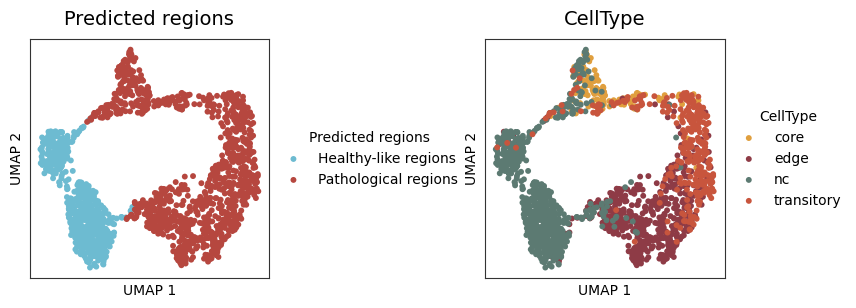

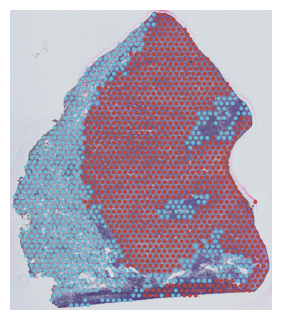

In [10]:
detection_figure = spapath_utils.plot_detection_umap(
    adata=adata_full,
    embed="cell_embed",
    section_id=DISEASE_SECTION,
    batch_key="batch",
    label_key="pred_label",
    label_palette=REGION_PALETTE,
    celltype_key="CellType",
    celltype_palette=CELLTYPE_PALETTE,
    seed=SEED,
    point_size=18,
    save=FIGURE_DIR / f"{DISEASE_SECTION}_detection_umap.png",
)

he_prediction_figure = spapath_utils.plot_prediction_on_he(
    adata=adata_full,
    image_path=HE_IMAGE_PATH,
    section_id=DISEASE_SECTION,
    batch_key="batch",
    label_key="pred_label",
    spatial_key="spatial",
    label_palette=REGION_PALETTE,
    coordinate_scale=0.08828852,
    point_size=8,
    save=FIGURE_DIR / f"{DISEASE_SECTION}_prediction_on_he.png",
)

## 8. Build the all-gene disease dataset

In [11]:
disease_data = spapath_utils.build_disease_data(
    adata_full=adata_full,
    disease_adata_all_genes=disease_adata_all_genes,
    disease_section=DISEASE_SECTION,
)

## 9. Calculate TC-to-LE enrichment

In [12]:
tc_le_results = spapath_utils.calculate_tc_le_enrichment(
    adata=disease_data,
    gene_table=TC_LE_GENE_FILE,
    label_key="pred_label",
    pathological_label="Pathological regions",
    dist_key="cell_gene_dist",
    n_permutations=5000,
    min_genes=5,
    seed=SEED,
)

Calculating distance enrichment: 100%|██████████| 2/2 [00:04<00:00,  2.25s/it]


## 10. Plot TC-to-LE enrichment on H&E

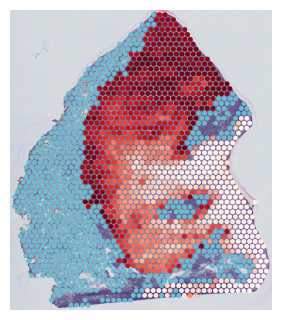

In [13]:
tc_le_he_figure = spapath_utils.plot_score_on_he(
    adata=disease_data,
    image_path=HE_IMAGE_PATH,
    score_key="TC_to_LE_score",
    label_key="pred_label",
    focus_label="Pathological regions",
    spatial_key="spatial",
    coordinate_scale=0.08828852,
    background_color=REGION_PALETTE["Healthy-like regions"],
    cmap="Reds",
    point_scale=0.85,
    figsize=(3, 3),
    save=FIGURE_DIR / f"{DISEASE_SECTION}_TC_to_LE_score_on_he.png",
)

## 11. Compare enrichment across ground-truth tissue classes

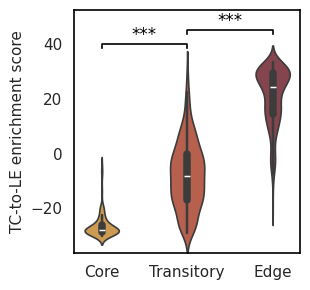

In [14]:
tc_le_figure, tc_le_statistics = spapath_utils.plot_tc_le_violin(
    adata=disease_data,
    score_key="TC_to_LE_score",
    group_key="CellType",
    predicted_label_key="pred_label",
    truth_label_key="truth_label",
    pathological_label="Pathological regions",
    group_order=["core", "transitory", "edge"],
    palette=CELLTYPE_PALETTE,
    save=FIGURE_DIR / f"{DISEASE_SECTION}_TC_to_LE_violin.png",
)